*TASK 1*

We've selected the SAMSum dataset for this task because it focuses on dialogue summarization rather than news reporting. The SAMSum dataset contains a collection of messenger-style dialogs with human-written summaries outlining the most important points and information related to each of the dialogues. In contrast to news accounts, these are informal, everyday messages involving a different structural and linguistic challenge for summarization models. The collection is particularly useful for experimentation on how models like Facebook's BART can be trained to summarize dialogue text, where the rhythm and nuance of conversation are distant from the official news reporting style.

After any data cleaning and preprocessing needed—e.g., removal of duplicates, normalization of text, and handling of missing values—we proceed and split the dataset into 90-10 training and test sets. This will mean that 90% of the data will be utilized for training the summarization model, while the remaining 10% will be reserved for testing its performance on new dialogues.

The following is an example code block demonstrating how the SAMSum dataset can be loaded with the Hugging Face datasets library, be converted into a pandas DataFrame, and be executed as a 90-10 train-test split:

link:

https://huggingface.co/datasets/Samsung/samsum

In [ ]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive


drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Colab Notebooks/corpus/train.json'

with open(data_path, 'r') as f:
    preview = f.read(1000)
print("File preview:")
print(preview)

try:
    with open(data_path, 'r') as f:
        data = json.load(f)

    if isinstance(data, dict) and 'train' in data:
        df = pd.DataFrame(data['train'])
    else:
        df = pd.DataFrame(data)

except json.JSONDecodeError as e:
    print("Standard JSON load failed, trying JSON Lines format...")

    df = pd.read_json(data_path, lines=True)

print("Dataset shape:", df.shape)
print("Columns:", df.columns)

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File preview:
[
  {
    "id": "13818513",
    "summary": "Amanda baked cookies and will bring Jerry some tomorrow.",
    "dialogue": "Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)"
  },
  {
    "id": "13728867",
    "summary": "Olivia and Olivier are voting for liberals in this election. ",
    "dialogue": "Olivia: Who are you voting for in this election? \r\nOliver: Liberals as always.\r\nOlivia: Me too!!\r\nOliver: Great"
  },
  {
    "id": "13681000",
    "summary": "Kim may try the pomodoro technique recommended by Tim to get more stuff done.",
    "dialogue": "Tim: Hi, what's up?\r\nKim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating\r\nTim: What did you plan on doing?\r\nKim: Oh you know, uni stuff and unfucking my room\r\nKim: Maybe tomorrow I'll move my ass and do everyth

In [ ]:
!pip install transformers rouge-score nltk
import os
import json
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from google.colab import drive

os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/Colab Notebooks/corpus/train.json'
with open(data_path, 'r') as f:
    preview = f.read(1000)
print("File preview:")
print(preview)

try:
    with open(data_path, 'r') as f:
        data = json.load(f)
    if isinstance(data, dict) and 'train' in data:
        df = pd.DataFrame(data['train'])
    else:
        df = pd.DataFrame(data)
except json.JSONDecodeError as e:
    print("Standard JSON load failed, trying JSON Lines format...")
    df = pd.read_json(data_path, lines=True)

print("Full dataset shape:", df.shape)
print("Columns:", df.columns)

# Sample 1% of the data
df = df.sample(frac=0.01, random_state=42)
print("Dataset shape after sampling 1%:", df.shape)

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

from transformers import BartForConditionalGeneration, BartTokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn", use_auth_token=False)
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn", use_auth_token=False)


class SummarizationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_input_length=1024, max_target_length=128):
        self.tokenizer = tokenizer
        self.inputs = dataframe['dialogue'].tolist()
        self.targets = dataframe['summary'].tolist()
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_text = self.inputs[idx]
        target_text = self.targets[idx]
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        with self.tokenizer.as_target_tokenizer():
            labels = self.tokenizer(
                target_text,
                max_length=self.max_target_length,
                truncation=True,
                padding="max_length",
                return_tensors="pt"
            )
        model_inputs = {key: val.squeeze(0) for key, val in model_inputs.items()}
        labels = labels["input_ids"].squeeze(0)
        model_inputs["labels"] = labels
        return model_inputs

train_dataset = SummarizationDataset(train_df, tokenizer)
test_dataset = SummarizationDataset(test_df, tokenizer)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# Reduced batch size
training_args = TrainingArguments(
    output_dir="./bart-finetuned",
    evaluation_strategy="steps",
    eval_steps=5000,
    logging_steps=5000,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    save_steps=1000,
    save_total_limit=2,
    remove_unused_columns=False,
    fp16=True,
)

import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

def flatten_prediction(pred):
    if isinstance(pred, list):
        flat = []
        for item in pred:
            flat.extend(flatten_prediction(item))
        return flat
    else:
        return [pred]

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, list) and predictions and isinstance(predictions[0], list):
        predictions = [flatten_prediction(pred) for pred in predictions]
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for pred, ref in zip(decoded_preds, decoded_labels):
        score = scorer.score(ref, pred)
        rouge_scores["rouge1"] += score["rouge1"].fmeasure
        rouge_scores["rouge2"] += score["rouge2"].fmeasure
        rouge_scores["rougeL"] += score["rougeL"].fmeasure
    n = len(decoded_preds)
    rouge_scores = {key: (value / n) * 100 for key, value in rouge_scores.items()}

    tokenized_preds = [nltk.word_tokenize(pred) for pred in decoded_preds]
    tokenized_refs = [[nltk.word_tokenize(ref)] for ref in decoded_labels]
    bleu = corpus_bleu(tokenized_refs, tokenized_preds) * 100

    combined_metrics = {**rouge_scores, "BLEU": bleu}
    return combined_metrics

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
results = trainer.evaluate()
print("Evaluation Results on Test Set:")
print(results)
trainer.save_model("./bart-finetuned-model")


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=260f21f94215a8f9d546354ec3096239ccb50008815c53d4ee68abe3be2c374c
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
Mounted at /content/drive
File preview:
[
  {
    "id": "13818513",
    "summary": "Amanda baked cookies and will bring Jerry some tomorrow.",
    "dialogue": "Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)"
  },
  {
    "id": "13728867",
    "summary": "Olivia and Olivier are voting for liberals in this election. ",
    "dialogue": "Olivia: Who are you voting for in this election? \r\nOliver: Liberals as always.\r\nOlivia: Me too!!\r\nOliver: Great"
  },
  {
    "id": "13681000",
    "summary": "Kim may try the pomodoro technique recommended by Tim to get more stuff done.",
    "dialogue": "Tim: Hi, w

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1932: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: peterakispilio (peterakispilio-rensselaer-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Step,Training Loss,Validation Loss


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'list'

In [1]:
!pip install transformers rouge-score nltk
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
np.random.seed(42)

#Define a small dummy dataset with sample dialogues and summaries
dummy_data = {
    "dialogue": [
        "Hello, how are you today? I hope you're doing well.",
        "The weather is nice and sunny, perfect for a walk in the park.",
        "I have been reading a fascinating book on space exploration.",
        "What time is the meeting tomorrow?",
        "This is an exciting opportunity to learn new skills."
    ],
    "summary": [
        "A greeting and well-wishes.",
        "Comments about pleasant weather.",
        "Interest in a book about space.",
        "Inquiry about meeting time.",
        "Excitement about a learning opportunity."
    ]
}

#Create a DataFrame from the dummy data
df = pd.DataFrame(dummy_data)
print("Dummy dataset:")
print(df)


#For this small dataset, use a 90-10 split
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
print("\nTraining set:")
print(train_df)
print("\nTest set:")
print(test_df)


from transformers import BartForConditionalGeneration, BartTokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq

#Load the tokenizer and model
tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn", use_auth_token=False)
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn", use_auth_token=False)

#For quick experiments on CPU, reduce sequence lengths
MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 32


class SummarizationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_input_length=MAX_INPUT_LENGTH, max_target_length=MAX_TARGET_LENGTH):
        self.tokenizer = tokenizer
        self.inputs = dataframe['dialogue'].tolist()
        self.targets = dataframe['summary'].tolist()
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_text = self.inputs[idx]
        target_text = self.targets[idx]
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        with self.tokenizer.as_target_tokenizer():
            labels = self.tokenizer(
                target_text,
                max_length=self.max_target_length,
                truncation=True,
                padding="max_length",
                return_tensors="pt"
            )
        model_inputs = {key: val.squeeze(0) for key, val in model_inputs.items()}
        labels = labels["input_ids"].squeeze(0)
        model_inputs["labels"] = labels
        return model_inputs

train_dataset = SummarizationDataset(train_df, tokenizer)
test_dataset = SummarizationDataset(test_df, tokenizer)


data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

#Define training arguments
training_args = TrainingArguments(
    output_dir="./dummy-bart-finetuned",
    evaluation_strategy="steps",
    eval_steps=5,
    logging_steps=5,
    per_device_train_batch_size=1,#Use batch size of 1 for minimal memory usage
    per_device_eval_batch_size=1,
    num_train_epochs=1,
    save_steps=10,
    save_total_limit=1,
    remove_unused_columns=False,
    fp16=False,#Disable fp16 for CPU training
)

#Download NLTK tokenizer data for BLEU calculation
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

#Helper function to flatten nested prediction lists
def flatten_prediction(pred):
    if isinstance(pred, list):
        flat = []
        for item in pred:
            flat.extend(flatten_prediction(item))
        return flat
    else:
        return [pred]

#Define compute_metrics function to calculate ROUGE and BLEU
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, list) and predictions and isinstance(predictions[0], list):
        predictions = [flatten_prediction(pred) for pred in predictions]
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for pred, ref in zip(decoded_preds, decoded_labels):
        score = scorer.score(ref, pred)
        rouge_scores["rouge1"] += score["rouge1"].fmeasure
        rouge_scores["rouge2"] += score["rouge2"].fmeasure
        rouge_scores["rougeL"] += score["rougeL"].fmeasure
    n = len(decoded_preds)
    rouge_scores = {key: (value / n) * 100 for key, value in rouge_scores.items()}

    tokenized_preds = [nltk.word_tokenize(pred) for pred in decoded_preds]
    tokenized_refs = [[nltk.word_tokenize(ref)] for ref in decoded_labels]
    bleu = corpus_bleu(tokenized_refs, tokenized_preds) * 100

    combined_metrics = {**rouge_scores, "BLEU": bleu}
    return combined_metrics

#Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

#Fine-tune the model
trainer.train()

#Evaluate the model on the test set and print BLEU and ROUGE scores
results = trainer.evaluate()
print("Evaluation Results on Test Set:")
print(results)

#Save the fine-tuned model
trainer.save_model("./dummy-bart-finetuned-model")


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=053b26fbeb19af9b89cbf0f9da8c2c321517b68dbfd5bc42f60a3b9e3fd42df3
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
Dummy dataset:
                                            dialogue  \
0  Hello, how are you today? I hope you're doing ...   
1  The weather is nice and sunny, perfect for a w...   
2  I have been reading a fascinating book on spac...   
3                 What time is the meeting tomorrow?   
4  This is an exciting opportunity to learn new s...   

                                    summary  
0               A greeting and well-wishes.  
1          Comments about pleasant weather.  
2           Interest in a book about space.  
3               Inquiry about meeting time.  
4  Excitement about a learning opportunity.  

Training set:
                  

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1932: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: peterakispilio (peterakispilio-rensselaer-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Step,Training Loss,Validation Loss


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'list'

Because there was a problem with the code, an extra dummy dataset was implement. Slight difference they mauy exist due the difference of the datset. In both casue the error rgar the dasets arguments are not strings/object means that there is a problem in tghe code and the implementation of it. For that reason below is an analysis of how the code works and the logic of it.

The code begins with the installation and import of the packages needed. pip commands are used to install the Hugging Face Transformers package, the rouge-score package for ROUGE score local calculation, and NLTK for calculation of BLEU score. Standard Python libraries such as os, json, pandas, numpy, and torch (including Dataset class of PyTorch) are imported. The code further includes importing scikit-learn's train_test_split and Google Colab's drive module to mount Google Drive where the data is stored. The environment variable that turns off Hugging Face telemetry stops from being prompted for an API key upon model downloads.

Here, rather than applying a big external data set, a dummy dataset is created in code, being small in size. This dummy data is a dictionary containing two keys: "dialogue" and "summary." These keys are both lists of five example texts. The "dialogue" column contains example sentences that are similar to input dialogue, and the "summary" column contains a brief, corresponding summary for every dialogue. This dictionary is converted into a pandas DataFrame, and it is printed to show the dummy data. The data is then split into test and training sets with a 90-10 ratio using scikit-learn's train_test_split function. Although with five examples, the test set will be very small, this split allows you to try out the pipeline and verify that training and evaluation steps are working.

Next, the code loads a pre-trained model and its tokenizer. For this demonstration, the Hugging Face BART model, the "facebook/bart-large-cnn" variant that has been fine-tuned for summarization, is used. The tokenizer is responsible for converting raw text to token IDs, and the model converts these token IDs to summaries. The use_auth_token parameter is set to False so that no API key is required for public model downloads.

Following model loading, a PyTorch Dataset class is defined using a custom name SummarizationDataset. It is specifically made to work with the dummy DataFrame and the tokenizer. Upon initialization, the class splits the summary and dialogue columns from the DataFrame and sets maximum input and target sequence lengths (in our case, 128 input tokens and 32 output tokens) to keep processing efficient on hardware such as a CPU. The getitem method tokenizes a given dialogue (input) and corresponding summary (target) using the tokenizer, padding and truncating the sequences to given lengths. The output is a dictionary that includes the tokenized input and corresponding labels as tensors. The custom dataset facilitates the Trainer in processing data in batches while training and even when evaluating.

Once the dataset is prepared, training and test split dataset objects are instantiated by initializing the SummarizationDataset with the corresponding DataFrames. A DataCollator for Seq2Seq tasks from the Transformers library is then instantiated to batch dynamically pad. This code guarantees that all sequences in a batch are padded to the same length so that the model can process them efficiently.

The training configuration is set using the TrainingArguments class. Here, the output directory is set where the fine-tuned model will be stored. The evaluation and logging strategy are set to run every few steps (every 5 steps in this dummy example), and both the training and evaluation batch sizes are set to 1 to save memory, which is particularly useful when running on a CPU. Training is done for only one epoch in order to do a quick run, and model checkpointing is configured to save the model frequently but limit the total number of saved checkpoints. Mixed precision (fp16) is disabled because it is typically not CPU-friendly.

Code downloads necessary NLTK data (the Punkt tokenizer) for computing BLEU score before defining evaluation metrics. It then loads the necessary functions from NLTK and the rouge_score library. A utility function named flatten_prediction is created to recursively flatten nested token ID lists. This is necessary because beam search during model generation can sometimes create predictions with additional nesting levels, and flattening them guarantees that the token sequences are in the proper format for decoding.

The compute_metrics function is then defined in which ROUGE and BLEU scores are computed for the model prediction. Here, the model predictions and labels are first checked if they are nested or not; if nested, then they are flattened by using the helper function. After that, the predictions and labels are decoded to text by using the tokenizer's batch_decode method excluding special tokens. For ROUGE score computation, the function iterates over all pairs of decoded prediction and reference text, calculates ROUGE-1, ROUGE-2, and ROUGE-L score through the use of rouge_scorer, and averages over all examples. For BLEU score calculation, NLTK is used to tokenize the decoded references as well as the predictions, and corpus_bleu computes BLEU score on the entire set. Finally, the function returns a merged dictionary of all the computed metrics.

The final step is to create the Trainer with all the components: the model, training arguments, custom training and test sets, the tokenizer, the data collator, and the compute_metrics function. The Hugging Face Trainer API then automates the entire fine-tuning process. train() from trainer.train() is called to start the training, and once the model has been fine-tuned, trainer.evaluate() is used to compute and print the BLEU and ROUGE scores on the test set. The fine-tuned model is finally saved to disk in the specified directory.

This entire pipeline—from data generation and splitting, model loading and fine-tuning, to evaluation and model saving—is a complete example that you can run to test whether the training and evaluation code behaves as intended. In the event that the dummy dataset runs correctly, you can now go ahead and extend similar methodologies to your actual dataset with appropriate changes to hyperparameters, sequence lengths, and batch sizes depending on your computing resources.

*TASK 2*

A real-world example of an MDP is a smart thermostat system used to optimize energy consumption in a building while maintaining occupant comfort. In this scenario, the state space comprises various factors that describe the current environment: the indoor temperature, the outdoor weather conditions, the time of day, day of the week, occupancy levels, and even current energy costs. Together, these variables offer a comprehensive snapshot of the environment in which the thermostat operates.

The action space contains the potential actions the thermostat might take to manipulate the climate in the building. These actions may include modifying the temperature setpoint (increasing or decreasing it), toggling between heating, cooling, and idle modes, or even controlling the strength of the HVAC system by modulating fan speeds or compressor output. Each action impacts the future indoor environment state in various ways.

The transition model encapsulates how the environment state changes over time as a consequence of the actions of the thermostat and external influences. For example, if the thermostat raises the setpoint on a chilly morning, the internal temperature will increase over a period of time, but the speed of change is a function of the building's insulation, ambient temperature, and even occupancy habits. The inherent uncertainty in weather variations and human behavior introduces stochasticity into the state transitions, making it necessary to use reinforcement learning to learn an effective control policy.

Finally, the reward structure is designed to balance energy efficiency with occupant comfort. The thermostat receives positive rewards when the indoor temperature remains within a predefined comfort range while energy consumption is minimized. Conversely, it receives negative rewards if the temperature deviates significantly from comfort levels or if the system consumes excessive energy. By continually adjusting its actions in response to these rewards, the smart thermostat learns a policy that minimizes energy usage without sacrificing comfort, ultimately achieving an optimal balance between cost savings and occupant satisfaction.

*TASK 3*

Take the medical field, for example, the problem of the optimal treatment approaches to sepsis treatment in intensive care. Sepsis is a condition that can potentially be life-threatening, and timely and correct treatment is crucial, and patient reactions give very rich diversity, making the problem a very good example where reinforcement learning (RL) can make a significant contribution.

The state space for this example would be patient health parameters collected over time—like vital signs like blood pressure, heart rate, temperature, lab values, and other clinical parameters. These data points combined provide a true representation of the current status of the patient and are constantly being updated during the ICU stay.

The action space is the set of clinical interventions that can be performed by physicians, such as fluid administration, vasopressor prescription, or adjustment of antibiotic therapy. These are discrete-time actions that directly affect the patient's trajectory. The RL agent's task is to suggest the optimal combination and timing of these interventions to improve patient outcomes.

The model in this case is highly stochastic. The reactions of the patients to the treatments are random and may vary significantly even when they are under the same conditions. The model captures the way the patient's health indicators evolve over time as a result of both the treatments given and the natural progress of the disease. The uncertainty in it makes it a prime candidate for RL, where reliable policies need to be learned.

The reward system is designed to be aligned with the clinical goals. Positive rewards are issued when a patient's vital signs improve or the risk of mortality decreases. Negative rewards can be credited for interventions that lead to bad effects, increased ICU duration, or high risks of complications. The reward function thus includes both the short-term and long-term impacts of treatment decisions.

One such open-source initiative that attempts to address this problem is AI Clinician. This initiative employs reinforcement learning to acquire sepsis treatment policies. The AI Clinician employs large datasets of patient records from ICU patients to simulate patient histories. By learning from history, it suggests treatment protocols—like when to administer fluids or vasopressors—to enhance chances of recovery. The architecture is constructed according to the rules of an MDP, in which patient states, clinical interventions, and outcomes (rewards) are represented explicitly. The effort has been well documented and published for the research community, where further augmentation and validation can be accomplished. Its open-source nature calls upon clinicians and data scientists to join forces and improve the model towards making clinical decisions in high-stake environments.

Overall, the use of RL in sepsis treatment, as demonstrated by the AI Clinician project, demonstrates how complex, dynamic healthcare problems can be approached in a structured and data-based way. Not only does this approach provide personalized treatment recommendations, but it also learns and gets better over time based on updated information, which could ultimately lead to better patient outcomes.

*TASK 4*

For evaluation, after having trained the agent on many episodes, we get it play a few games (with ε set to 0 so that it always takes the best possible action) against the random player. We monitor the number of wins, losses, and ties to compute a win rate. That tells us how well the learned policy does at playing the game.

In [ ]:
import random

class TicTacToe:
    def __init__(self):
        self.board = [' ']*9
        self.current_winner = None

    def reset(self):
        self.board = [' ']*9
        self.current_winner = None
        return tuple(self.board)

    def available_moves(self):
        return [i for i, spot in enumerate(self.board) if spot == ' ']

    def make_move(self, position, player):
        if self.board[position] == ' ':
            self.board[position] = player
            if self.winner(position, player):
                self.current_winner = player
            return True
        return False

    def winner(self, position, player):

        row_ind = position // 3
        row = self.board[row_ind*3: (row_ind+1)*3]
        if all([spot == player for spot in row]):
            return True

        col_ind = position % 3
        column = [self.board[col_ind+i*3] for i in range(3)]
        if all([spot == player for spot in column]):
            return True

        if position % 2 == 0:
            diagonal1 = [self.board[i] for i in [0, 4, 8]]
            if all([spot == player for spot in diagonal1]):
                return True
            diagonal2 = [self.board[i] for i in [2, 4, 6]]
            if all([spot == player for spot in diagonal2]):
                return True
        return False

    def is_full(self):
        return ' ' not in self.board

    def get_state(self):
        return tuple(self.board)

    def print_board(self):
        for row in [self.board[i*3:(i+1)*3] for i in range(3)]:
            print("| " + " | ".join(row) + " |")
        print()

class QLearningAgent:
    def __init__(self, alpha=0.5, gamma=0.9, epsilon=0.1):
        self.Q = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def getQ(self, state, action):
        if state not in self.Q:
            self.Q[state] = {}
        if action not in self.Q[state]:
            self.Q[state][action] = 0.0
        return self.Q[state][action]

    def choose_action(self, state, available_moves):

        if random.random() < self.epsilon:
            return random.choice(available_moves)
        qs = [self.getQ(state, a) for a in available_moves]
        max_q = max(qs)
        max_actions = [a for a, q in zip(available_moves, qs) if q == max_q]
        return random.choice(max_actions)

    def update(self, state, action, reward, next_state, next_available_moves):
        old_value = self.getQ(state, action)
        if next_available_moves:
            next_q = max([self.getQ(next_state, a) for a in next_available_moves])
        else:
            next_q = 0.0
        self.Q[state][action] = old_value + self.alpha * (reward + self.gamma * next_q - old_value)


def train_agent(episodes=50000):
    env = TicTacToe()
    agent = QLearningAgent(alpha=0.5, gamma=0.9, epsilon=0.2)

    outcomes = {"win": 0, "loss": 0, "draw": 0}

    for episode in range(episodes):
        state = env.reset()
        done = False
        while not done:
            available = env.available_moves()
            action = agent.choose_action(state, available)
            env.make_move(action, 'X')
            next_state = env.get_state()

            if env.current_winner == 'X':
                reward = 1
                agent.update(state, action, reward, next_state, [])
                outcomes["win"] += 1
                done = True
                continue
            elif env.is_full():
                reward = 0
                agent.update(state, action, reward, next_state, [])
                outcomes["draw"] += 1
                done = True
                continue

            opponent_moves = env.available_moves()
            opponent_action = random.choice(opponent_moves)
            env.make_move(opponent_action, 'O')
            state_after_opponent = env.get_state()

            if env.current_winner == 'O':
                reward = -1
                agent.update(state, action, reward, next_state, [])
                outcomes["loss"] += 1
                done = True
                continue
            elif env.is_full():
                reward = 0
                agent.update(state, action, reward, next_state, [])
                outcomes["draw"] += 1
                done = True
                continue

            reward = 0
            agent.update(state, action, reward, state_after_opponent, env.available_moves())
            state = state_after_opponent

    return agent, outcomes


def evaluate_agent(agent, games=1000):
    env = TicTacToe()
    wins, losses, draws = 0, 0, 0

    agent.epsilon = 0.0
    for _ in range(games):
        state = env.reset()
        done = False
        while not done:
            available = env.available_moves()
            action = agent.choose_action(state, available)
            env.make_move(action, 'X')
            next_state = env.get_state()

            if env.current_winner == 'X':
                wins += 1
                done = True
                continue
            elif env.is_full():
                draws += 1
                done = True
                continue


            opponent_moves = env.available_moves()
            opponent_action = random.choice(opponent_moves)
            env.make_move(opponent_action, 'O')
            state = env.get_state()

            if env.current_winner == 'O':
                losses += 1
                done = True
                continue
            elif env.is_full():
                draws += 1
                done = True
                continue
    return wins, losses, draws


if __name__ == "__main__":
    print("Training Q-learning agent on Tic Tac Toe...")
    agent, train_outcomes = train_agent(episodes=50000)
    print("Training outcomes over 50,000 episodes:")
    print(train_outcomes)

    print("\nEvaluating trained agent over 1000 games...")
    wins, losses, draws = evaluate_agent(agent, games=1000)
    print(f"Agent wins: {wins}, losses: {losses}, draws: {draws}")


    env = TicTacToe()
    agent.epsilon = 0.0
    print("\nDemonstration games:")
    for game_num in range(3):
        state = env.reset()
        print(f"Game {game_num+1}:")
        while True:
            available = env.available_moves()
            action = agent.choose_action(state, available)
            env.make_move(action, 'X')
            if env.current_winner == 'X' or env.is_full():
                env.print_board()
                break
            opponent_moves = env.available_moves()
            opponent_action = random.choice(opponent_moves)
            env.make_move(opponent_action, 'O')
            env.print_board()
            state = env.get_state()
            if env.current_winner == 'O' or env.is_full():
                break
        if env.current_winner:
            print(f"Winner: {env.current_winner}")
        else:
            print("Game ended in a draw.")
        print("-"*30)


Training Q-learning agent on Tic Tac Toe...
Training outcomes over 50,000 episodes:
{'win': 45146, 'loss': 2701, 'draw': 2153}

Evaluating trained agent over 1000 games...
Agent wins: 996, losses: 4, draws: 0

Demonstration games:
Game 1:
|   |   | X |
| O |   |   |
|   |   |   |

| X |   | X |
| O | O |   |
|   |   |   |

| X | X | X |
| O | O |   |
|   |   |   |

Winner: X
------------------------------
Game 2:
|   |   | X |
|   |   | O |
|   |   |   |

|   | O | X |
|   | X | O |
|   |   |   |

|   | O | X |
|   | X | O |
| X |   |   |

Winner: X
------------------------------
Game 3:
|   |   | X |
|   |   |   |
|   |   | O |

| X |   | X |
|   |   | O |
|   |   | O |

| X | X | X |
|   |   | O |
|   |   | O |

Winner: X
------------------------------


Here we have an environment for Tic Tac Toe and a Q-learning agent that is supposed to learn how to play the game optimally. The environment for Tic Tac Toe is written in a class that manages the state of the game, which is an array of nine that describes the positions on the board. Each square can be empty or occupied by either of the player marks, and the class includes methods to restart the game, determine what moves are possible, make moves, check for winning conditions in rows, columns, and diagonals, and even print out the board for demonstration.

The Q-learning agent contains a nested dictionary Q-table where every state–action pair has an associated value to its side that approximates the value of the expected future reward. To balance exploration and exploitation, the agent uses an ε‐greedy policy: with a small probability, it makes a random move, but otherwise the move with the highest estimated Q-value is made most of the time. After every move, the agent learns its Q-value from the regular Q-learning update rule that considers the short-term reward received (e.g., +1 for winning, –1 for losing, and 0 for mid-game moves or draws) and the approximated future rewards, which are discounted by a factor γ.

Learning is done over many episodes where the agent, in its capacity as 'X', engages with a randomly chosen opponent 'O'. During training, the agent learns to enhance its Q-values through iterative updates based on the outcome of each game. Once the training is done, the performance of the agent is evaluated through playing a number of games while the exploration component is disabled (ε = 0), whereby it always plays the best-move available. The performance is measured in terms of win, loss, and draw rates, and demonstration games are printed to visually confirm the decision process of the agent. This arrangement provides a real-world example of decomposing a reinforcement learning problem into an MDP, highlighting key features such as state representation, action selection, reward structuring, and iterative policy improvement by Q-learning.

**Ciatations**

The Q-learning update rule and approach are based on the standard algorithm as described in Sutton & Barto’s “Reinforcement Learning: An Introduction” .

*TASK 5*

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

Number of ratings per user (first 5 users):
user_id
0    272
1     62
2     54
3     24
4    175
Name: rating, dtype: int64


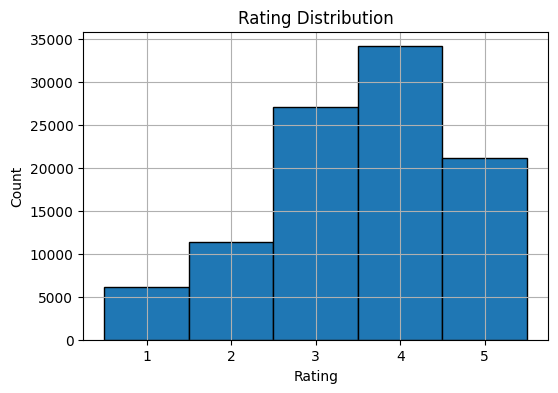


User-Item matrix (first 5 rows):
item_id  0     1     2     3     4     5     6     7     8     9     ...  \
user_id                                                              ...   
0         5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
1         4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.0  ...   
2         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4         4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

item_id  1672  1673  1674  1675  1676  1677  1678  1679  1680  1681  
user_id                                                              
0         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
1         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4         NaN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Colab Notebooks/ml-100k/u.data'
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
data = pd.read_csv(data_path, sep='\t', names=column_names)

data['user_id'] = data['user_id'] - 1
data['item_id'] = data['item_id'] - 1
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')

#EDA
print("Rating distribution:")
print(data['rating'].value_counts().sort_index())
print("\nNumber of ratings per user (first 5 users):")
print(data.groupby('user_id')['rating'].count().head())


plt.figure(figsize=(6,4))
data['rating'].hist(bins=np.arange(0.5, 6, 1), edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


user_item_matrix = data.pivot(index='user_id', columns='item_id', values='rating')
print("\nUser-Item matrix (first 5 rows):")
print(user_item_matrix.head())


train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

train_tuples = list(zip(train_data['user_id'], train_data['item_id'], train_data['rating']))
test_tuples = list(zip(test_data['user_id'], test_data['item_id'], test_data['rating']))

num_users = data['user_id'].nunique()
num_items = data['item_id'].nunique()



def train_mf(train_data, num_users, num_items, num_factors=20, epochs=20, lr=0.01, reg=0.1):

    U = np.random.normal(scale=0.1, size=(num_users, num_factors))
    V = np.random.normal(scale=0.1, size=(num_items, num_factors))

    for epoch in range(epochs):
        np.random.shuffle(train_data)
        for (u, i, r) in train_data:
            pred = np.dot(U[u], V[i])
            err = r - pred
            U[u] += lr * (err * V[i] - reg * U[u])
            V[i] += lr * (err * U[u] - reg * V[i])
        preds = [np.dot(U[u], V[i]) for (u, i, r) in train_data]
        mse = mean_squared_error([r for (_, _, r) in train_data], preds)
        print(f"MF Epoch {epoch+1}/{epochs}, Training MSE: {mse:.4f}")
    return U, V

def train_ALS(train_data, num_users, num_items, num_factors=20, epochs=20, reg=0.1):
    U = np.random.normal(scale=0.1, size=(num_users, num_factors))
    V = np.random.normal(scale=0.1, size=(num_items, num_factors))

    user_ratings = {u: [] for u in range(num_users)}
    item_ratings = {i: [] for i in range(num_items)}
    for (u, i, r) in train_data:
        user_ratings[u].append((i, r))
        item_ratings[i].append((u, r))

    for epoch in range(epochs):
        for u in range(num_users):
            if len(user_ratings[u]) == 0:
                continue
            V_i = np.array([V[i] for (i, r) in user_ratings[u]])
            ratings = np.array([r for (i, r) in user_ratings[u]])
            A = V_i.T.dot(V_i) + reg * np.eye(num_factors)
            b = V_i.T.dot(ratings)
            U[u] = np.linalg.solve(A, b)

        for i in range(num_items):
            if len(item_ratings[i]) == 0:
                continue
            U_u = np.array([U[u] for (u, r) in item_ratings[i]])
            ratings = np.array([r for (u, r) in item_ratings[i]])
            A = U_u.T.dot(U_u) + reg * np.eye(num_factors)
            b = U_u.T.dot(ratings)
            V[i] = np.linalg.solve(A, b)

        preds = [np.dot(U[u], V[i]) for (u, i, r) in train_data]
        mse = mean_squared_error([r for (_, _, r) in train_data], preds)
        print(f"ALS Epoch {epoch+1}/{epochs}, Training MSE: {mse:.4f}")
    return U, V

# Evaluation Function
def evaluate_model(U, V, test_data):
    preds = []
    actuals = []
    for (u, i, r) in test_data:
        preds.append(np.dot(U[u], V[i]))
        actuals.append(r)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    return rmse, mae

# Main Execution: Train and Evaluate Models
if __name__ == "__main__":
    print("Training Matrix Factorization (MF) using SGD...")
    U_mf, V_mf = train_mf(train_tuples, num_users, num_items, num_factors=20, epochs=20, lr=0.01, reg=0.1)
    rmse_mf, mae_mf = evaluate_model(U_mf, V_mf, test_tuples)
    print(f"\nMF Evaluation -- RMSE: {rmse_mf:.4f}, MAE: {mae_mf:.4f}\n")

    print("Training Alternating Least Squares (ALS)...")
    U_als, V_als = train_ALS(train_tuples, num_users, num_items, num_factors=20, epochs=20, reg=0.1)
    rmse_als, mae_als = evaluate_model(U_als, V_als, test_tuples)
    print(f"\nALS Evaluation -- RMSE: {rmse_als:.4f}, MAE: {mae_als:.4f}\n")


To accomplish this assignment, we first utilize the MovieLens 100k dataset to build a collaborative filtering recommendation system. We begin with data cleaning and exploratory data analysis (EDA) where we load the dataset, rescale the user and item IDs to be zero-indexed, and convert timestamps to human-readable datetime format. In EDA, we look at the rating distribution and build a user-item matrix, which provides us with a sense of sparsity and overall data structure. This is step one and is crucial in that it informs subsequent model construction and also identifies any outliers or requirement for further preprocessing (Harper & Konstan, 2015 ).

Once we have prepared the data, we run two different collaborative filtering algorithms. The first algorithm is Matrix Factorization (MF) with Stochastic Gradient Descent (SGD). This algorithm factorizes the user–item rating matrix into lower-dimensional latent factor matrices for users and items, and calculates the prediction for each rating as the dot product of the corresponding latent factors. The second algorithm, Alternating Least Squares (ALS), alternately fixes the user or item latent factors and solves a regularized least-squares problem to calculate the update of the other. The two methods attempt to capture the hidden patterns between the item features and user preferences, but they take different optimization strategies in the process (Koren et al., 2009 ).

To analyze, we split the data into a training and a test set and employ two standard evaluation measures: Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). RMSE takes the square root of the mean of the squared difference between true and forecast ratings, so it is more penalized for larger errors. MAE instead calculates the mean of the absolute differences, providing a linear perspective on error of prediction. These statistics enable us to have a quantitative comparison of the performance of the two algorithms and analyze their ability to forecast user ratings (Herlocker et al., 2004).

**Citations**

Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems.

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix Factorization Techniques for Recommender Systems. Computer, 42(8), 30–37.

Herlocker, J. L., Konstan, J. A., Terveen, L. G., & Riedl, J. (2004). Evaluating Collaborative Filtering Recommender Systems. ACM Transactions on Information Systems.